/Users/vi/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/Users/vi/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/5l/xvvkbgln1qz502f2b5fvbfj40000gn/T/ipykernel_5662/1944260708.py:7: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
/Users/vi/miniconda3/lib/python3.13/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https:


image 1/1 /Users/vi/TTCS/source/SourceCodePlate/training/../samples/img_plate_6.png: 960x896 3 plates, 267.3ms
Speed: 6.8ms preprocess, 267.3ms inference, 8.5ms postprocess per image at shape (1, 3, 960, 896)
(1358, 1258, 3)


/var/folders/5l/xvvkbgln1qz502f2b5fvbfj40000gn/T/ipykernel_5662/1944260708.py:28: DeprecationWarning: Please use `predict` instead.
  result = ocr.ocr(crop)


Plate: 59-U2 099.78 | Confidence: 0.99
Plate: 59-U2 099.78 | Confidence: 0.97
Plate: 51F 371.95 | Confidence: 0.95


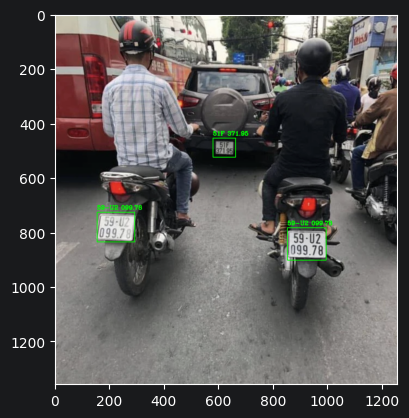

In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR
import cv2

model = YOLO("../model/best_plate_detection.pt")
ocr = PaddleOCR(use_angle_cls=True, lang='en')
predict = model("../samples/img_plate_6.png")
img = cv2.imread("../samples/img_plate_6.png")
print(img.shape)

for r in predict:

    boxes = r.boxes.xyxy

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        offset_w = int((x2 - x1) * 0.1)
        offset_h = int((y2 - y1) * 0.2)
        x1_crop = max(0, x1 - offset_w)
        y1_crop = max(0, y1 - offset_h)
        x2_crop = min(img.shape[1], x2 + 2*offset_w)
        y2_crop = min(img.shape[0], y2 + 2*offset_h)

        crop = img[y1_crop:y2_crop, x1_crop:x2_crop]
        # cv2.imwrite("crop.png", crop)
        result = ocr.ocr(crop)
        plate = ""
        if result:
            texts = result[0]['rec_texts']
            scores = result[0]['rec_scores']
            plate = " ".join(texts)
        if len(scores) > 0:
            conf = sum(scores)/len(scores)

        if conf > 0:
            cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(img, plate, (x1, y1-10), cv2.FONT_HERSHEY_COMPLEX, 0.7, (0,255,0), 2)
        print(f"Plate: {plate} | Confidence: {conf:.2f}")
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

In [4]:
from paddleocr import PaddleOCR
ocr = PaddleOCR(use_angle_cls=True, lang='en')
result = ocr.ocr("../training/crop.png")
print(result)

/var/folders/5l/xvvkbgln1qz502f2b5fvbfj40000gn/T/ipykernel_16021/1501276862.py:2: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files

[{'input_path': '../training/crop.png', 'page_index': None, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'input_img': array([[[13, ..., 24],
        ...,
        [12, ..., 44]],

       ...,

       [[19, ..., 56],
        ...,
        [ 8, ..., 27]]], shape=(153, 109, 3), dtype=uint8), 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 0, 'rot_img': array([[[13, ..., 24],
        ...,
        [12, ..., 44]],

       ...,

       [[19, ..., 56],
        ...,
        [ 8, ..., 27]]], shape=(153, 109, 3), dtype=uint8), 'output_img': array([[[86, ..., 77],
        ...,
        [21, ..., 55]],

       ...,

       [[ 7, ..., 24],
        ...,
        [10, ..., 25]]], shape=(153, 109, 3), dtype=uint8)}, 'dt_polys': [array([[16, 23],
       ...,
       [16, 70]], shape=(4, 2), dtype=int16), array([[  9,  63],
       ...,
       [  9, 113]], shape=(4, 2), dtype=int16)], 'model_settings': {'use_doc_preprocessor': True, 'use_textlin

In [4]:
!paddleocr text_detection -i crop_0_0.jpg --save_path ./output

/Users/vi/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/Users/vi/miniconda3/lib/python3.13/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-OCRv5_server_det`.
[2026/04/24 07:27:19] paddleocr INFO: Processed item 0 in 74.71990585327148 ms
{'res': {'input_path': 'crop_0_0.jpg', 'page_index': None, 'dt_polys': array([], dtype=int16), 'dt_scores': []}}


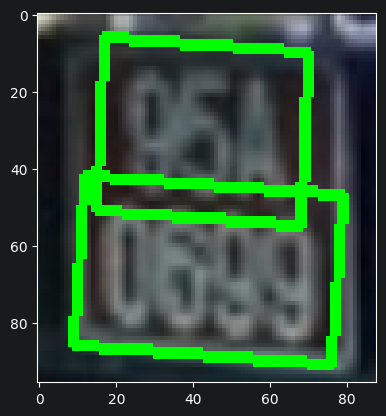

In [25]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("crop_0_5.jpg")
with open("output/crop_0_5_res.json", "r") as f:
    data = json.load(f)

boxes = data['dt_polys']
for box in boxes:
    pst = np.array(box, dtype=np.int32)
    cv2.polylines(img, [pst], True, (0, 255, 0), 2)

plt.imshow(img)

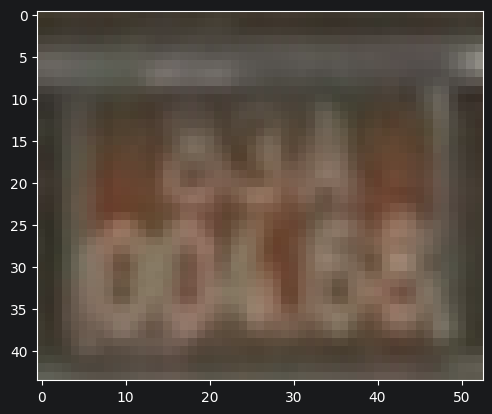

In [5]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("../../OpenCVTest/crop_0_0.jpg")
with open("output/crop_0_0_res.json", "r") as f:
    data = json.load(f)

boxes = data['dt_polys']
for box in boxes:
    pst = np.array(box, dtype=np.int32)
    cv2.polylines(img, [pst], True, (0, 255, 0), 2)

plt.imshow(img)